**Load from drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE = "/content/drive/MyDrive/cse428_project"
CACHE = os.path.join(DRIVE, "cache")
CKPT  = os.path.join(DRIVE, "checkpoints")
os.makedirs(CACHE, exist_ok=True)
os.makedirs(CKPT, exist_ok=True)

SEED = 42
print("Drive ready:", os.listdir(DRIVE))

Mounted at /content/drive
Drive ready: ['cache', 'checkpoints', 'baseline_vs_augmented_results.csv', 'improved_augmented_unet_attention_results.csv']


**Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import skimage

from skimage import io, transform, img_as_float


import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

torch.manual_seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


**Download dataset**

In [ ]:
import shutil, tarfile, urllib.request

RAW = "/content/data"
os.makedirs(RAW, exist_ok=True)

ARCHIVES = {
    "images.tar.gz":      "https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz",
    "annotations.tar.gz": "https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz",
}

for name, url in ARCHIVES.items():
    cached = os.path.join(CACHE, name)
    local  = os.path.join(RAW, name)

    if os.path.exists(cached):
        print(f"{name}: restoring from Drive cache...")
        shutil.copy(cached, local)
    else:
        print(f"{name}: downloading...")
        urllib.request.urlretrieve(url, local)
        shutil.copy(local, cached)

    print(f"  extracting {name}...")
    with tarfile.open(local) as t:
        t.extractall(RAW)

IMG_DIR    = os.path.join(RAW, "images")
TRIMAP_DIR = os.path.join(RAW, "annotations", "trimaps")
print("done:", os.listdir(RAW))

images.tar.gz: restoring from Drive cache...
  extracting images.tar.gz...


/tmp/ipykernel_3567/2202080277.py:25: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall(RAW)


annotations.tar.gz: restoring from Drive cache...
  extracting annotations.tar.gz...
done: ['annotations', 'annotations.tar.gz', 'images.tar.gz', 'images']


**List, labels, split**

In [ ]:
def parse_label(filename):
    name = filename.rsplit("_", 1)[0]
    species = "Cat" if name[0].isupper() else "Dog"
    breed = name.replace("_", " ")
    return breed, species

all_files = sorted([f for f in os.listdir(IMG_DIR) if f.endswith(".jpg")])
breeds_all = sorted(set(parse_label(f)[0] for f in all_files))
breed_to_idx = {b: i for i, b in enumerate(breeds_all)}

print(f"Total images: {len(all_files)} | Breeds: {len(breeds_all)}")

# stratify by breed for a balanced split
strat_labels = [parse_label(f)[0] for f in all_files]

train_files, temp_files = train_test_split(
    all_files, test_size=0.30, random_state=SEED, stratify=strat_labels
)
strat_temp = [parse_label(f)[0] for f in temp_files]
val_files, test_files = train_test_split(
    temp_files, test_size=0.50, random_state=SEED, stratify=strat_temp
)

print(f"Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

train_breeds = set(parse_label(f)[0] for f in train_files)
val_breeds   = set(parse_label(f)[0] for f in val_files)
test_breeds  = set(parse_label(f)[0] for f in test_files)
print("Breeds in train/val/test/all:", len(train_breeds), len(val_breeds), len(test_breeds), len(breeds_all))
assert train_breeds == val_breeds == test_breeds == set(breeds_all)


Total images: 7390 | Breeds: 37
Train: 5173 | Val: 1108 | Test: 1109
Breeds in train/val/test/all: 37 37 37 37


**Dataset class**

In [ ]:
IMG_SIZE = 128

def augment_pair(img, mask):
    # random horizontal flip
    if np.random.rand() > 0.5:
        img = np.fliplr(img).copy()
        mask = np.fliplr(mask).copy()

    # slightly wider random rotation than the first augmented run
    if np.random.rand() > 0.5:
        angle = np.random.uniform(-20, 20)
        img = transform.rotate(img, angle, mode='reflect')
        mask = transform.rotate(mask, angle, order=0, mode='constant', cval=0, preserve_range=True)

    # stronger brightness/contrast jitter (image only)
    if np.random.rand() > 0.5:
        factor = np.random.uniform(0.7, 1.3)
        img = np.clip(img * factor, 0, 1)

    # random crop and resize zoom (image and mask)
    if np.random.rand() > 0.5:
        h, w = img.shape[:2]
        crop = np.random.uniform(0.8, 1.0)
        ch, cw = int(h * crop), int(w * crop)
        top = np.random.randint(0, h - ch + 1)
        left = np.random.randint(0, w - cw + 1)
        img = transform.resize(img[top:top+ch, left:left+cw], (h, w, 3), anti_aliasing=True)
        mask = transform.resize(mask[top:top+ch, left:left+cw], (h, w), order=0, preserve_range=True, anti_aliasing=False)

    return img, mask


class PetDataset(Dataset):
    def __init__(self, filenames, img_size=IMG_SIZE, augment=False):
        self.filenames = filenames
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname = self.filenames[idx]
        img_path = os.path.join(IMG_DIR, fname)
        mask_path = os.path.join(TRIMAP_DIR, fname.replace(".jpg", ".png"))

        img = io.imread(img_path)
        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)

        elif img.ndim == 3:
            c = img.shape[-1]
            if c == 1:
                img = np.repeat(img, 3, axis=-1)
            elif c == 4:
                img = img[:, :, :3]
        img = np.squeeze(img)

        if img.ndim == 2:
            img = np.stack([img, img, img], axis=-1)
        assert img.ndim == 3 and img.shape[-1] == 3, f"Bad image shape {img.shape} for {fname}"

        img = img_as_float(img)
        img = transform.resize(img, (self.img_size, self.img_size, 3), anti_aliasing=True)

        mask = io.imread(mask_path)
        mask = np.squeeze(mask)
        if mask.ndim == 3:
            mask = mask[:, :, 0]
        mask = transform.resize(mask, (self.img_size, self.img_size),
                                 order=0, preserve_range=True, anti_aliasing=False)
        mask = mask.astype(np.uint8)
        binary_mask = np.where(mask == 2, 0, 1).astype(np.float32)

        if self.augment:
            img, binary_mask = augment_pair(img, binary_mask)
            binary_mask = (binary_mask > 0.5).astype(np.float32)

        breed, species = parse_label(fname)
        label = breed_to_idx[breed]

        img_t = torch.tensor(img.copy(), dtype=torch.float32).permute(2, 0, 1)
        mask_t = torch.tensor(binary_mask.copy(), dtype=torch.float32)
        label_t = torch.tensor(label, dtype=torch.long)

        return img_t, mask_t, label_t


**Normalization from train set**

In [ ]:
train_ds_raw = PetDataset(train_files)
loader_stats = DataLoader(train_ds_raw, batch_size=64, shuffle=False)

mean = torch.zeros(3)
std  = torch.zeros(3)
n_samples = 0

for imgs, _, _ in loader_stats:
    b = imgs.size(0)
    imgs = imgs.view(b, 3, -1)
    mean += imgs.mean(dim=2).sum(dim=0)
    std  += imgs.std(dim=2).sum(dim=0)
    n_samples += b

mean /= n_samples
std  /= n_samples
print("Channel mean:", mean.tolist())
print("Channel std :", std.tolist())

MEAN = mean.view(3, 1, 1)
STD  = std.view(3, 1, 1)

Channel mean: [0.4810957908630371, 0.44991323351860046, 0.3968307077884674]
Channel std : [0.22242169082164764, 0.2197561264038086, 0.22171184420585632]


**Normalized dataset**

In [ ]:
class NormalizedPetDataset(PetDataset):
    def __getitem__(self, idx):
        img_t, mask_t, label_t = super().__getitem__(idx)
        img_t = (img_t - MEAN) / (STD + 1e-8)
        return img_t, mask_t, label_t

BATCH_SIZE = 16

train_ds = NormalizedPetDataset(train_files, augment=True)   # augmentation ON
val_ds   = NormalizedPetDataset(val_files, augment=False)    # no for val/test
test_ds  = NormalizedPetDataset(test_files, augment=False)

_loader_kwargs = {
    "num_workers": 2,
    "pin_memory": torch.cuda.is_available(),
}
if _loader_kwargs["num_workers"] > 0:
    _loader_kwargs.update({"persistent_workers": True, "prefetch_factor": 2})

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **_loader_kwargs)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)


**3×3 visualization**

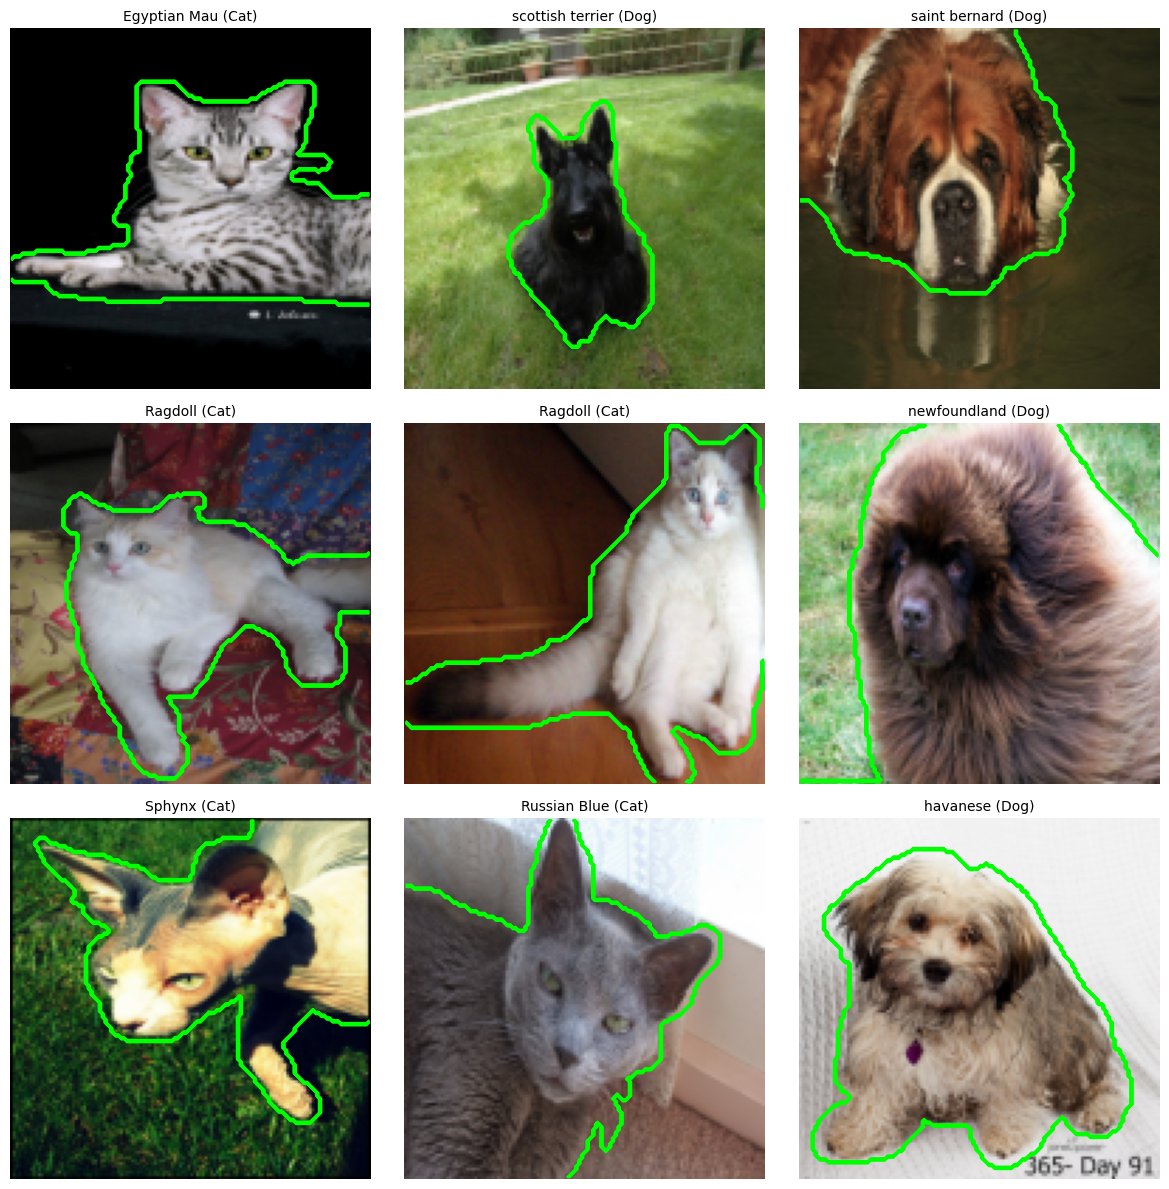

In [ ]:
import random

def show_random_grid(filenames, n=9):
    indices = random.sample(range(len(filenames)), n)
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()

    raw_ds = PetDataset(filenames)  # unnormalized for display
    for ax, idx in zip(axes, indices):
        img_t, mask_t, label_t = raw_ds[idx]
        img = img_t.permute(1, 2, 0).numpy()
        mask = mask_t.numpy()
        breed, species = parse_label(filenames[idx])

        ax.imshow(img)
        ax.contour(mask, colors='lime', linewidths=1.5)
        ax.set_title(f"{breed} ({species})", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

show_random_grid(train_files)

**Convolution Block**

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

**Encoder (full 4 level depth)**

In [ ]:
class UNetEncoder(nn.Module):
    def __init__(self, in_channels=3, first_out_channel=32):
        super().__init__()
        c = first_out_channel
        self.enc1 = ConvBlock(in_channels, c)       # 32
        self.enc2 = ConvBlock(c, c*2)                # 64
        self.enc3 = ConvBlock(c*2, c*4)               # 128
        self.enc4 = ConvBlock(c*4, c*8)               # 256
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x1 = self.enc1(x)               # 32  x IMG_SIZE
        x2 = self.enc2(self.pool(x1))   # 64  x IMG_SIZE/2
        x3 = self.enc3(self.pool(x2))   # 128 x IMG_SIZE/4
        x4 = self.enc4(self.pool(x3))   # 256 x IMG_SIZE/8
        return x1, x2, x3, x4

**Bottleneck**

In [ ]:
class UNetBottleneck(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.enc = ConvBlock(in_channels, in_channels*2)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        return self.enc(self.pool(x))   # 512 x IMG_SIZE/16

**Decoder (Plain U-net)**

In [ ]:
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(2*out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([skip, x], dim=1)
        x = self.conv(x)
        return x

**Decoder (full 4-level)**

In [ ]:
class UNetDecoder(nn.Module):
    def __init__(self, in_channels=512):
        super().__init__()
        self.decode1 = DecoderBlock(in_channels, in_channels//2)       # 512->256
        self.decode2 = DecoderBlock(in_channels//2, in_channels//4)    # 256->128
        self.decode3 = DecoderBlock(in_channels//4, in_channels//8)    # 128->64
        self.decode4 = DecoderBlock(in_channels//8, in_channels//16)   # 64->32

        self.final_conv = nn.Conv2d(in_channels//16, 1, kernel_size=1)

    def forward(self, x5, x4, x3, x2, x1):
        x = self.decode1(x5, x4)
        x = self.decode2(x, x3)
        x = self.decode3(x, x2)
        x = self.decode4(x, x1)
        x = self.final_conv(x).squeeze(1)   # [B, H, W]
        return x

**Classifier head**

In [ ]:
class Classifier(nn.Module):
    def __init__(self, in_channels, num_classes, dropout_p=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.drop1 = nn.Dropout2d(dropout_p)

        self.conv2 = nn.Conv2d(in_channels, in_channels // 2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // 2)
        self.drop2 = nn.Dropout(dropout_p)

        self.conv3 = nn.Conv2d(in_channels // 2, num_classes, kernel_size=1)

    def forward(self, x):
      x = F.relu(self.bn1(self.conv1(x)))
      x = self.drop1(x)
      x = F.relu(self.bn2(self.conv2(x)))
      x = F.adaptive_avg_pool2d(x, 1)
      x = x.flatten(1)
      x = self.drop2(x)
      x = self.conv3(x.unsqueeze(-1).unsqueeze(-1)).squeeze(-1).squeeze(-1)
      return x

print("Classifier updated: dropout_p is now configurable (default 0.5, unchanged for existing code)")

Classifier updated: dropout_p is now configurable (default 0.5, unchanged for existing code)


**Attention gate**

In [ ]:
class AttentionGate(nn.Module):
    def __init__(self, gate_channels, skip_channels, inter_channels):
        super().__init__()
        # W_g: project the gating signal (from decoder, coarser resolution)
        self.W_g = nn.Sequential(
            nn.Conv2d(gate_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        # W_x: project the skip connection (from encoder, finer resolution)
        self.W_x = nn.Sequential(
            nn.Conv2d(skip_channels, inter_channels, kernel_size=1),
            nn.BatchNorm2d(inter_channels)
        )
        # psi: produce a single-channel attention map in [0,1]
        self.psi = nn.Sequential(
            nn.Conv2d(inter_channels, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, gate, skip):
        # gate: decoder feature (coarser), skip: encoder feature (finer) - same spatial size expected
        g1 = self.W_g(gate)
        x1 = self.W_x(skip)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)          # attention coefficients, shape [B,1,H,W]
        return skip * psi            # re-weighted skip connection

**Attention decoder**

In [ ]:
class AttentionDecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.attn = AttentionGate(gate_channels=out_channels, skip_channels=out_channels,
                                    inter_channels=out_channels//2)
        self.conv = nn.Sequential(
            nn.Conv2d(2*out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)                    # upsample decoder feature to match skip's resolution
        skip_weighted = self.attn(gate=x, skip=skip)   # attention-gate the skip connection
        x = torch.cat([skip_weighted, x], dim=1)
        x = self.conv(x)
        return x

**Attention U-Net decoder**

In [ ]:
class AttentionUNetDecoder(nn.Module):
    def __init__(self, in_channels=512):
        super().__init__()
        self.decode1 = AttentionDecoderBlock(in_channels, in_channels//2)
        self.decode2 = AttentionDecoderBlock(in_channels//2, in_channels//4)
        self.decode3 = AttentionDecoderBlock(in_channels//4, in_channels//8)
        self.decode4 = AttentionDecoderBlock(in_channels//8, in_channels//16)

        self.final_conv = nn.Conv2d(in_channels//16, 1, kernel_size=1)

    def forward(self, x5, x4, x3, x2, x1):
        x = self.decode1(x5, x4)
        x = self.decode2(x, x3)
        x = self.decode3(x, x2)
        x = self.decode4(x, x1)
        x = self.final_conv(x).squeeze(1)
        return x

**Model checker**

In [ ]:
NUM_CLASSES = len(breeds_all)
BASE_CH = 32

WHICH = "attn"   # current model preview

def build_model(which):
    enc = UNetEncoder(in_channels=3, first_out_channel=BASE_CH).to(device)
    bot = UNetBottleneck(BASE_CH*8).to(device)

    if which == "unet":
        dec = UNetDecoder(in_channels=BASE_CH*16).to(device)
    elif which == "attn":
        dec = AttentionUNetDecoder(in_channels=BASE_CH*16).to(device)
    else:
        raise ValueError("which must be 'unet' or 'attn'")

    cls = Classifier(in_channels=BASE_CH*16, num_classes=NUM_CLASSES).to(device)
    return enc, bot, dec, cls

encoder, bottleneck, decoder, classifier = build_model(WHICH)
print(f"Built {WHICH} | classes: {NUM_CLASSES}")


Built attn | classes: 37


**Loss**

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, epsilon=1.):
        super().__init__()
        self.epsilon = epsilon  # avoids 0/0 when a mask has no foreground pixels at all

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)  # raw logits -> probabilities
        preds = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)

        intersection = (preds * targets).sum(dim=1)
        dice = (2. * intersection + self.epsilon) / (preds.sum(dim=1) + targets.sum(dim=1) + self.epsilon)
        return 1 - dice.mean()

bce_loss_fn = nn.BCEWithLogitsLoss()
dice_loss_fn = DiceLoss()

**Class weights for the classifier**

In [ ]:
train_labels = [breed_to_idx[parse_label(f)[0]] for f in train_files]
class_weights = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=train_labels)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

classifier_loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

**Segmentation metrics**

In [ ]:
def calculate_iou(y_pred_logits, y_true, threshold=0.5, eps=1e-6):
    y_pred = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred > threshold).float()
    y_pred = y_pred.view(y_pred.size(0), -1)
    y_true = y_true.view(y_true.size(0), -1)

    intersection = (y_pred * y_true).sum(dim=1)
    union = y_pred.sum(dim=1) + y_true.sum(dim=1) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()

def calculate_dice_coeff(y_pred_logits, y_true, threshold=0.5, eps=1e-6):
    y_pred = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred > threshold).float()
    y_pred = y_pred.view(y_pred.size(0), -1)
    y_true = y_true.view(y_true.size(0), -1)

    intersection = (y_pred * y_true).sum(dim=1)
    dice = (2. * intersection + eps) / (y_pred.sum(dim=1) + y_true.sum(dim=1) + eps)
    return dice.mean().item()

def calculate_pixel_accuracy(y_pred_logits, y_true, threshold=0.5):
    y_pred = torch.sigmoid(y_pred_logits)
    y_pred = (y_pred > threshold).float()
    correct = (y_pred == y_true).float().mean()
    return correct.item()

**Accuracy, precision, recall, F1**

In [ ]:
def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )
    return acc, precision, recall, f1

**Optimizer**

In [ ]:
LR = 1e-4
EPOCHS = 30
WEIGHT_DECAY = 1e-3

def configure_optimizer():
    global optimizer, scheduler
    params = (list(encoder.parameters()) + list(bottleneck.parameters()) +
              list(decoder.parameters()) + list(classifier.parameters()))
    optimizer = torch.optim.AdamW(params, lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    return optimizer, scheduler

optimizer, scheduler = configure_optimizer()


**Checkpoint save**

In [ ]:
def save_ckpt(tag, epoch, history, best_score, monitor=None):
    torch.save({
        "encoder": encoder.state_dict(),
        "bottleneck": bottleneck.state_dict(),
        "decoder": decoder.state_dict(),
        "classifier": classifier.state_dict(),
        "optim": optimizer.state_dict(),
        "sched": scheduler.state_dict(),
        "epoch": epoch,
        "history": history,
        "best_val": best_score,
        "best_score": best_score,
        "monitor": monitor,
        "mean": MEAN, "std": STD,
        "which": WHICH,
        "architecture": "regularized_classifier_v2",
        "weight_decay": WEIGHT_DECAY,
        "eval_results": {},
        "eval_metadata": {},
    }, os.path.join(CKPT, f"{tag}_last.pt"))

def save_best_ckpt(tag):
    src = os.path.join(CKPT, f"{tag}_last.pt")
    dst = os.path.join(CKPT, f"{tag}_best.pt")
    shutil.copy(src, dst)

def load_ckpt(path):
    return torch.load(path, map_location=device, weights_only=False)


**One epoch of training**

In [ ]:
W_BCE, W_DICE, W_CLS = 0.2, 0.8, 0.5   # tunable joint-loss weights, same pattern as Lab 8

def run_epoch(loader, train=True):
    if train:
        encoder.train(); bottleneck.train(); decoder.train(); classifier.train()
    else:
        encoder.eval(); bottleneck.eval(); decoder.eval(); classifier.eval()

    total_bce, total_dice, total_cls = 0.0, 0.0, 0.0
    total_iou, total_dicecoef, total_pixacc = 0.0, 0.0, 0.0
    all_labels, all_preds = [], []
    n_batches = 0

    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for imgs, masks, labels in loader:
            imgs, masks, labels = imgs.to(device), masks.to(device), labels.to(device)

            x1, x2, x3, x4 = encoder(imgs)
            x5 = bottleneck(x4)
            mask_logits = decoder(x5, x4, x3, x2, x1)
            label_logits = classifier(x5)

            bce = bce_loss_fn(mask_logits, masks)
            dice = dice_loss_fn(mask_logits, masks)
            cls_loss = classifier_loss_fn(label_logits, labels)

            loss = W_BCE*bce + W_DICE*dice + W_CLS*cls_loss

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_bce += bce.item()
            total_dice += dice.item()
            total_cls += cls_loss.item()
            total_iou += calculate_iou(mask_logits, masks)
            total_dicecoef += calculate_dice_coeff(mask_logits, masks)
            total_pixacc += calculate_pixel_accuracy(mask_logits, masks)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(label_logits.argmax(dim=1).cpu().numpy().tolist())
            n_batches += 1

    acc, prec, rec, f1 = classification_metrics(all_labels, all_preds)

    return {
        "bce": total_bce/n_batches, "dice_loss": total_dice/n_batches, "cls_loss": total_cls/n_batches,
        "iou": total_iou/n_batches, "dice_coef": total_dicecoef/n_batches, "pix_acc": total_pixacc/n_batches,
        "cls_acc": acc, "cls_prec": prec, "cls_rec": rec, "cls_f1": f1,
    }

**Full Training**

In [ ]:
def _score_from_monitor(val_metrics, monitor):
    if monitor == "val_cls_acc":
        return val_metrics["cls_acc"]
    if monitor == "val_iou":
        return val_metrics["iou"]
    if monitor == "combined":
        return 0.5 * val_metrics["iou"] + 0.5 * val_metrics["cls_acc"]
    raise ValueError("monitor must be 'val_cls_acc', 'val_iou', or 'combined'")


def fit(tag, epochs=EPOCHS, resume=False, patience=5, monitor="val_cls_acc"):
    history, best_score, start_epoch = [], -1.0, 1

    if resume:
        last_path = os.path.join(CKPT, f"{tag}_last.pt")
        if os.path.exists(last_path):
            ck = load_ckpt(last_path)
            encoder.load_state_dict(ck["encoder"])
            bottleneck.load_state_dict(ck["bottleneck"])
            decoder.load_state_dict(ck["decoder"])
            classifier.load_state_dict(ck["classifier"])
            optimizer.load_state_dict(ck["optim"])
            scheduler.load_state_dict(ck["sched"])
            history = ck["history"]
            best_score = ck.get("best_score", ck.get("best_val", -1.0))
            start_epoch = ck["epoch"] + 1
            print(f"Resumed {tag} from epoch {ck['epoch']}, best {monitor} {best_score:.4f}")

    epochs_without_improvement = 0

    for epoch in range(start_epoch, epochs + 1):
        train_metrics = run_epoch(train_loader, train=True)
        val_metrics = run_epoch(val_loader, train=False)
        scheduler.step()

        score = _score_from_monitor(val_metrics, monitor)

        print(f"[{tag}] Epoch {epoch:3d}/{epochs} | "
              f"Train IoU:{train_metrics['iou']:.4f} Dice:{train_metrics['dice_coef']:.4f} "
              f"ClsAcc:{train_metrics['cls_acc']:.4f} | "
              f"Val IoU:{val_metrics['iou']:.4f} Dice:{val_metrics['dice_coef']:.4f} "
              f"ClsAcc:{val_metrics['cls_acc']:.4f}")

        history.append({"epoch": epoch, "train": train_metrics, "val": val_metrics, "monitor": monitor, "score": score})

        if score > best_score:
            best_score = score
            epochs_without_improvement = 0
            save_ckpt(tag, epoch, history, best_score, monitor=monitor)
            save_best_ckpt(tag)
            print(f"  -> new best {monitor} {best_score:.4f}, saved {tag}_best.pt")
        else:
            epochs_without_improvement += 1
            save_ckpt(tag, epoch, history, best_score, monitor=monitor)
            print(f"  -> no improvement for {epochs_without_improvement} epoch(s)")
            if epochs_without_improvement >= patience:
                print(f"  -> Early stopping: no improvement for {patience} epochs.")
                break

    return history


**Run Full training**

In [ ]:
IMPROVED_AUGMENTED_RUNS = {
    "unet": "unet_aug2",
    "attn": "attn_aug2",
}

histories_aug2 = {}
for which, tag in IMPROVED_AUGMENTED_RUNS.items():
    WHICH = which
    encoder, bottleneck, decoder, classifier = build_model(WHICH)
    optimizer, scheduler = configure_optimizer()
    print(f"\nTraining improved augmented model: {tag}")
    histories_aug2[tag] = fit(tag, epochs=EPOCHS, resume=False, patience=5, monitor="val_cls_acc")



Training improved augmented model: unet_aug2
[unet_aug2] Epoch   1/30 | Train IoU:0.6140 Dice:0.7438 ClsAcc:0.0570 | Val IoU:0.6344 Dice:0.7622 ClsAcc:0.1390
  -> new best val_cls_acc 0.1390, saved unet_aug2_best.pt
[unet_aug2] Epoch   2/30 | Train IoU:0.6910 Dice:0.8050 ClsAcc:0.0938 | Val IoU:0.7123 Dice:0.8192 ClsAcc:0.1634
  -> new best val_cls_acc 0.1634, saved unet_aug2_best.pt
[unet_aug2] Epoch   3/30 | Train IoU:0.7253 Dice:0.8291 ClsAcc:0.1295 | Val IoU:0.7400 Dice:0.8378 ClsAcc:0.1850
  -> new best val_cls_acc 0.1850, saved unet_aug2_best.pt
[unet_aug2] Epoch   4/30 | Train IoU:0.7470 Dice:0.8440 ClsAcc:0.1662 | Val IoU:0.7563 Dice:0.8499 ClsAcc:0.1742
  -> no improvement for 1 epoch(s)
[unet_aug2] Epoch   5/30 | Train IoU:0.7626 Dice:0.8547 ClsAcc:0.2146 | Val IoU:0.7662 Dice:0.8556 ClsAcc:0.2608
  -> new best val_cls_acc 0.2608, saved unet_aug2_best.pt
[unet_aug2] Epoch   6/30 | Train IoU:0.7753 Dice:0.8635 ClsAcc:0.2486 | Val IoU:0.7878 Dice:0.8709 ClsAcc:0.3439
  -> new 

**Evaluation function**

In [ ]:
def _segmentation_metrics_from_logits(mask_logits, masks, eps=1e-6):

    preds = (mask_logits > 0).to(masks.dtype)
    preds_flat = preds.flatten(1)
    masks_flat = masks.flatten(1)

    intersection = (preds_flat * masks_flat).sum(dim=1)
    pred_sum = preds_flat.sum(dim=1)
    mask_sum = masks_flat.sum(dim=1)
    union = pred_sum + mask_sum - intersection

    iou = ((intersection + eps) / (union + eps)).mean()
    dice = ((2.0 * intersection + eps) / (pred_sum + mask_sum + eps)).mean()
    pixacc = (preds == masks).to(torch.float32).mean()
    return iou, dice, pixacc


def evaluate_full(enc, bot, dec, cls, loader, mean=None, std=None):
    enc.eval(); bot.eval(); dec.eval(); cls.eval()

    total_iou = torch.zeros((), device=device)
    total_dice = torch.zeros((), device=device)
    total_pixacc = torch.zeros((), device=device)
    all_labels, all_preds = [], []
    n_batches = 0

    with torch.inference_mode():
        for imgs, masks, labels in loader:
            imgs = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            x1, x2, x3, x4 = enc(imgs)
            x5 = bot(x4)
            mask_logits = dec(x5, x4, x3, x2, x1)
            label_logits = cls(x5)

            iou, dice, pixacc = _segmentation_metrics_from_logits(mask_logits, masks)
            total_iou += iou
            total_dice += dice
            total_pixacc += pixacc

            all_labels.extend(labels.tolist())
            all_preds.extend(label_logits.argmax(dim=1).cpu().tolist())
            n_batches += 1

    acc, prec, rec, f1 = classification_metrics(all_labels, all_preds)

    return {
        "mIoU": (total_iou / n_batches).item(),
        "Dice": (total_dice / n_batches).item(),
        "PixelAcc": (total_pixacc / n_batches).item(),
        "ClsAcc": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
    }


**Run evaluation**

In [ ]:
import pandas as pd
from datetime import datetime

AUGMENTED_TAGS = ["unet_aug2", "attn_aug2"]
MODEL_DISPLAY_NAMES = {
    "unet_aug2": "aug_unet",
    "attn_aug2": "aug_atten",
}

def model_type_from_checkpoint_or_tag(ck, tag):
    model_type = ck.get("which")
    if model_type in {"unet", "attn"}:
        return model_type
    if tag.startswith("unet"):
        return "unet"
    if tag.startswith("attn"):
        return "attn"
    raise ValueError(f"Unknown checkpoint model type for tag: {tag}")

def build_and_load(tag):
    ck = load_ckpt(os.path.join(CKPT, f"{tag}_best.pt"))
    enc = UNetEncoder(in_channels=3, first_out_channel=BASE_CH).to(device)
    bot = UNetBottleneck(BASE_CH*8).to(device)
    model_type = model_type_from_checkpoint_or_tag(ck, tag)
    if model_type == "unet":
        dec = UNetDecoder(in_channels=BASE_CH*16).to(device)
    elif model_type == "attn":
        dec = AttentionUNetDecoder(in_channels=BASE_CH*16).to(device)
    cls = Classifier(in_channels=BASE_CH*16, num_classes=NUM_CLASSES).to(device)

    enc.load_state_dict(ck["encoder"])
    bot.load_state_dict(ck["bottleneck"])
    dec.load_state_dict(ck["decoder"])
    cls.load_state_dict(ck["classifier"])
    return enc, bot, dec, cls


def checkpoint_best_train_val_metrics(tag):
    ck = load_ckpt(os.path.join(CKPT, f"{tag}_best.pt"))
    history = ck.get("history", [])
    if not history:
        return None
    monitor = ck.get("monitor", "val_cls_acc")
    if all("score" in row for row in history):
        best_epoch = max(history, key=lambda row: row["score"])
    else:
        best_epoch = max(history, key=lambda row: row["val"]["cls_acc"])
    return {
        "epoch": best_epoch["epoch"],
        "Train_from_history": best_epoch["train"],
        "Val_from_history": best_epoch["val"],
        "best_score": ck.get("best_score", ck.get("best_val")),
        "monitor": monitor,
        "note": "Checkpoint history has train/val training-loop metrics only. Test metrics and full evaluate_full() metrics are saved under eval_results after running evaluation once.",
    }


def _ckpt_path(tag):
    return os.path.join(CKPT, f"{tag}_best.pt")


def load_eval_results_from_ckpt(tag, required_splits=("Train", "Val", "Test")):
    ck = load_ckpt(_ckpt_path(tag))
    eval_results = ck.get("eval_results", {})
    if all(split in eval_results for split in required_splits):
        return eval_results
    return None


def save_eval_results_to_ckpt(tag, eval_results, train_eval_augmented):
    path = _ckpt_path(tag)
    ck = load_ckpt(path)
    ck["eval_results"] = eval_results
    ck["eval_metadata"] = {
        "saved_at": datetime.now().isoformat(timespec="seconds"),
        "model_name": MODEL_DISPLAY_NAMES.get(tag, tag),
        "checkpoint_tag": tag,
        "metrics": ["mIoU", "Dice", "PixelAcc", "ClsAcc", "Precision", "Recall", "F1"],
        "splits": list(eval_results.keys()),
        "img_size": IMG_SIZE,
        "num_classes": NUM_CLASSES,
        "batch_size": BATCH_SIZE,
        "train_eval_augmented": train_eval_augmented,
        "architecture": ck.get("architecture", "regularized_classifier_v2"),
        "weight_decay": ck.get("weight_decay", WEIGHT_DECAY),
        "monitor": ck.get("monitor", "val_cls_acc"),
        "metric_note": "These are evaluate_full() metrics cached after inference so future loads do not need dataset re-evaluation.",
    }
    torch.save(ck, path)


def evaluate_or_load(tag, split_loaders, train_eval_augmented):
    cached = load_eval_results_from_ckpt(tag, required_splits=split_loaders.keys())
    if cached is not None:
        print(f"Loaded cached evaluation metrics from {tag}_best.pt")
        return {split: cached[split] for split in split_loaders.keys()}

    enc, bot, dec, cls = build_and_load(tag)
    eval_results = {
        split: evaluate_full(enc, bot, dec, cls, loader, MEAN, STD)
        for split, loader in split_loaders.items()
    }
    save_eval_results_to_ckpt(tag, eval_results, train_eval_augmented=train_eval_augmented)
    print(f"Evaluated {tag} once and saved metrics into {tag}_best.pt")
    return eval_results


def checkpoint_outputs(tag):
    ck = load_ckpt(_ckpt_path(tag))
    return {
        "model_name": MODEL_DISPLAY_NAMES.get(tag, tag),
        "checkpoint_tag": tag,
        "which": ck.get("which"),
        "architecture": ck.get("architecture"),
        "weight_decay": ck.get("weight_decay"),
        "monitor": ck.get("monitor"),
        "best_score": ck.get("best_score", ck.get("best_val")),
        "history": ck.get("history"),
        "eval_results": ck.get("eval_results", {}),
        "eval_metadata": ck.get("eval_metadata", {}),
        "full_comparison_table": ck.get("full_comparison_table", []),
    }

for tag in AUGMENTED_TAGS:
    info = checkpoint_best_train_val_metrics(tag)
    if info is not None:
        print(MODEL_DISPLAY_NAMES[tag], "best epoch in history:", info["epoch"], info["monitor"], round(info["best_score"], 4))


aug_unet best epoch in history: 28 val_cls_acc 0.7058
aug_atten best epoch in history: 29 val_cls_acc 0.6977


**Load evaluation metrics**

In [ ]:
train_ds_eval = NormalizedPetDataset(train_files, augment=False)
train_loader_eval = DataLoader(train_ds_eval, batch_size=BATCH_SIZE, shuffle=False, **_loader_kwargs)

results_aug = {}
for tag in AUGMENTED_TAGS:
    results_aug[tag] = evaluate_or_load(
        tag,
        {"Train": train_loader_eval, "Val": val_loader, "Test": test_loader},
        train_eval_augmented=False,
    )


Loaded cached evaluation metrics from unet_aug2_best.pt
Loaded cached evaluation metrics from attn_aug2_best.pt


**Summary table**


In [ ]:
def print_augmented_summary_table(tag):
    df = pd.DataFrame(results_aug[tag]).T.round(4)
    print(f"\n===== {MODEL_DISPLAY_NAMES[tag].upper()} Segmentation & Classification Summary =====")
    print(df.to_string())

for tag in AUGMENTED_TAGS:
    print_augmented_summary_table(tag)

comparison_rows = []
for tag in AUGMENTED_TAGS:
    for split in ["Train", "Val", "Test"]:
        row = {"Model": MODEL_DISPLAY_NAMES[tag], "Checkpoint": tag, "Split": split, **results_aug[tag][split]}
        comparison_rows.append(row)

full_comparison_df = pd.DataFrame(comparison_rows).round(4)
print(full_comparison_df.to_string(index=False))

full_comparison_records = full_comparison_df.to_dict(orient="records")
for tag in AUGMENTED_TAGS:
    path = _ckpt_path(tag)
    ck = load_ckpt(path)
    ck["full_comparison_table"] = full_comparison_records
    ck.setdefault("eval_metadata", {})["comparison_scope"] = "improved_augmented_only"
    torch.save(ck, path)

full_comparison_df.to_csv(os.path.join(DRIVE, "improved_augmented_unet_attention_results.csv"), index=False)
print("Saved improved augmented-only comparison table into unet_aug2_best.pt, attn_aug2_best.pt, and CSV.")



===== AUG_UNET Segmentation & Classification Summary =====
         mIoU    Dice  PixelAcc  ClsAcc  Precision  Recall      F1
Train  0.8792  0.9321    0.9491  0.9279     0.9289  0.9278  0.9273
Val    0.8479  0.9109    0.9342  0.7058     0.7126  0.7053  0.7037
Test   0.8526  0.9150    0.9375  0.6754     0.6811  0.6752  0.6702

===== AUG_ATTEN Segmentation & Classification Summary =====
         mIoU    Dice  PixelAcc  ClsAcc  Precision  Recall      F1
Train  0.8812  0.9333    0.9501  0.9204     0.9199  0.9201  0.9191
Val    0.8473  0.9100    0.9345  0.6977     0.7006  0.6970  0.6935
Test   0.8541  0.9157    0.9383  0.6961     0.7032  0.6959  0.6915
    Model Checkpoint Split   mIoU   Dice  PixelAcc  ClsAcc  Precision  Recall     F1
 aug_unet  unet_aug2 Train 0.8792 0.9321    0.9491  0.9279     0.9289  0.9278 0.9273
 aug_unet  unet_aug2   Val 0.8479 0.9109    0.9342  0.7058     0.7126  0.7053 0.7037
 aug_unet  unet_aug2  Test 0.8526 0.9150    0.9375  0.6754     0.6811  0.6752 0.6702
aug

**Prediction display**


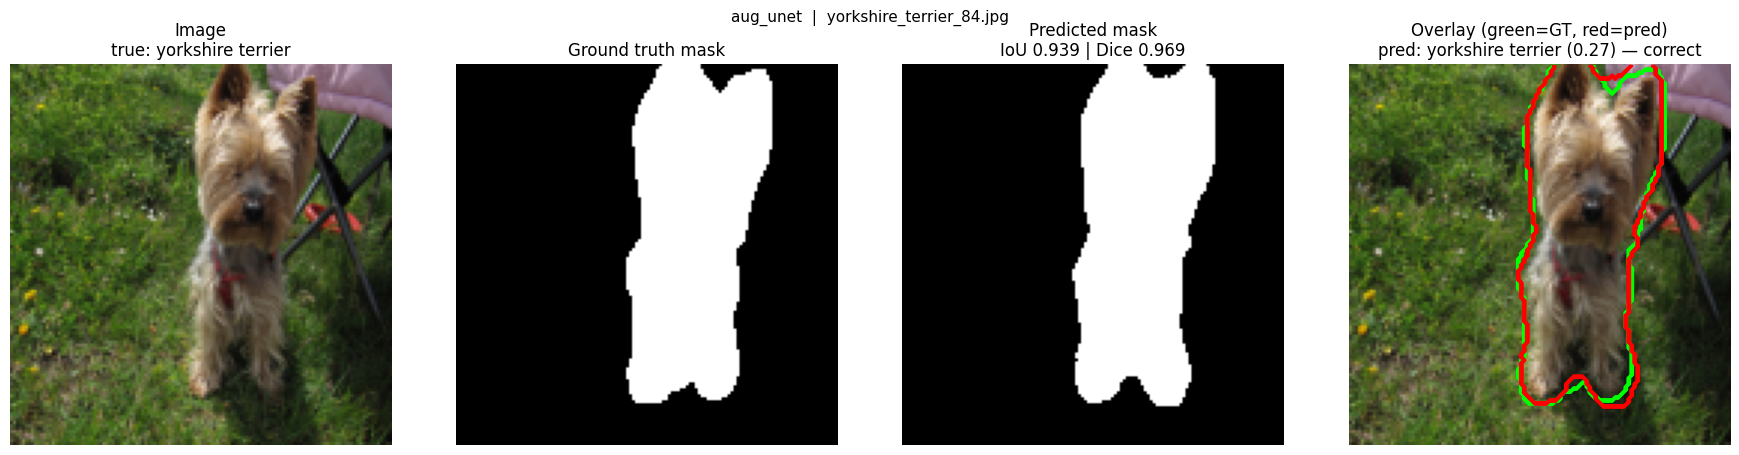

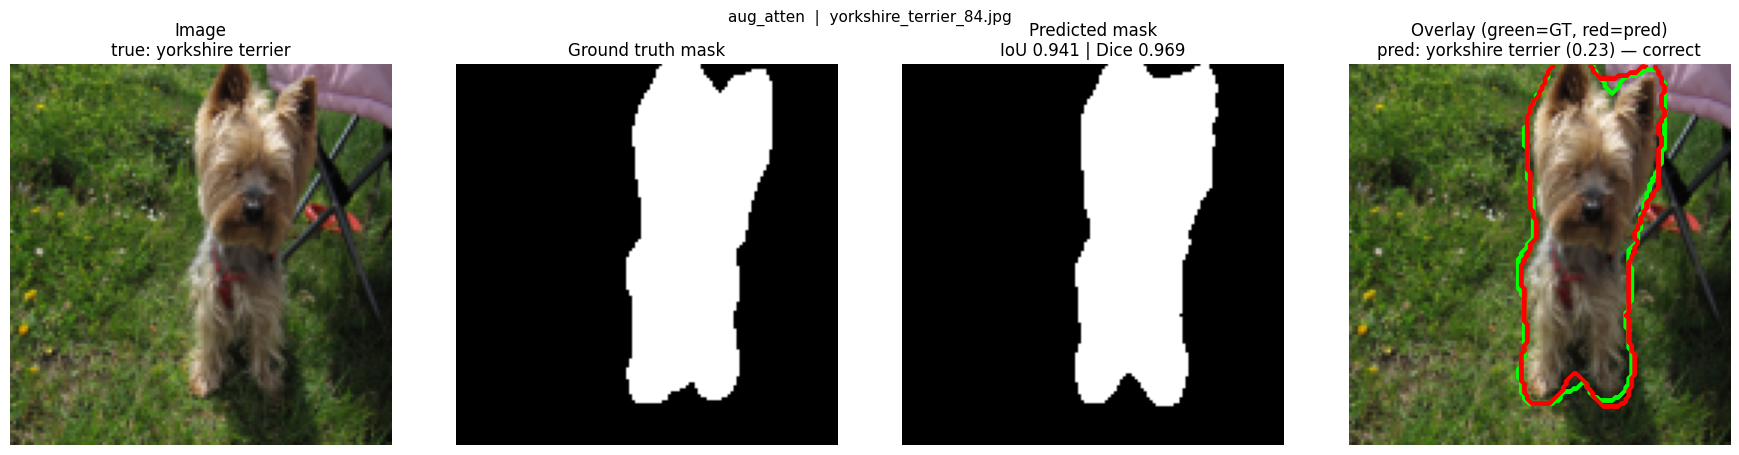

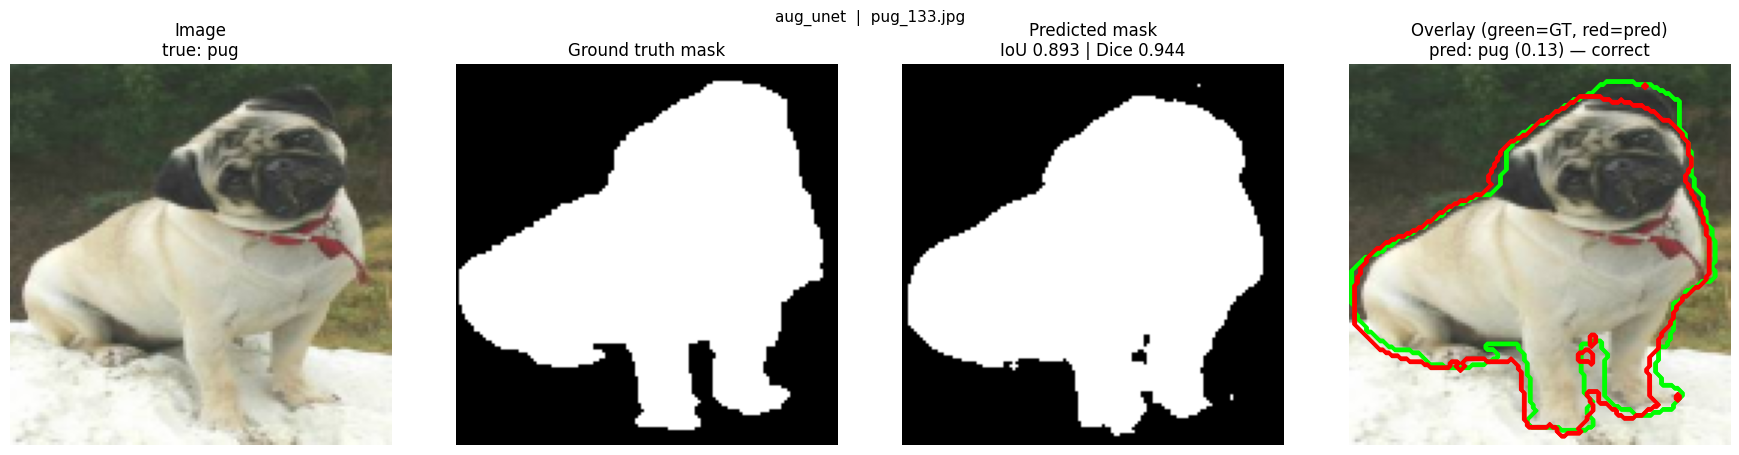

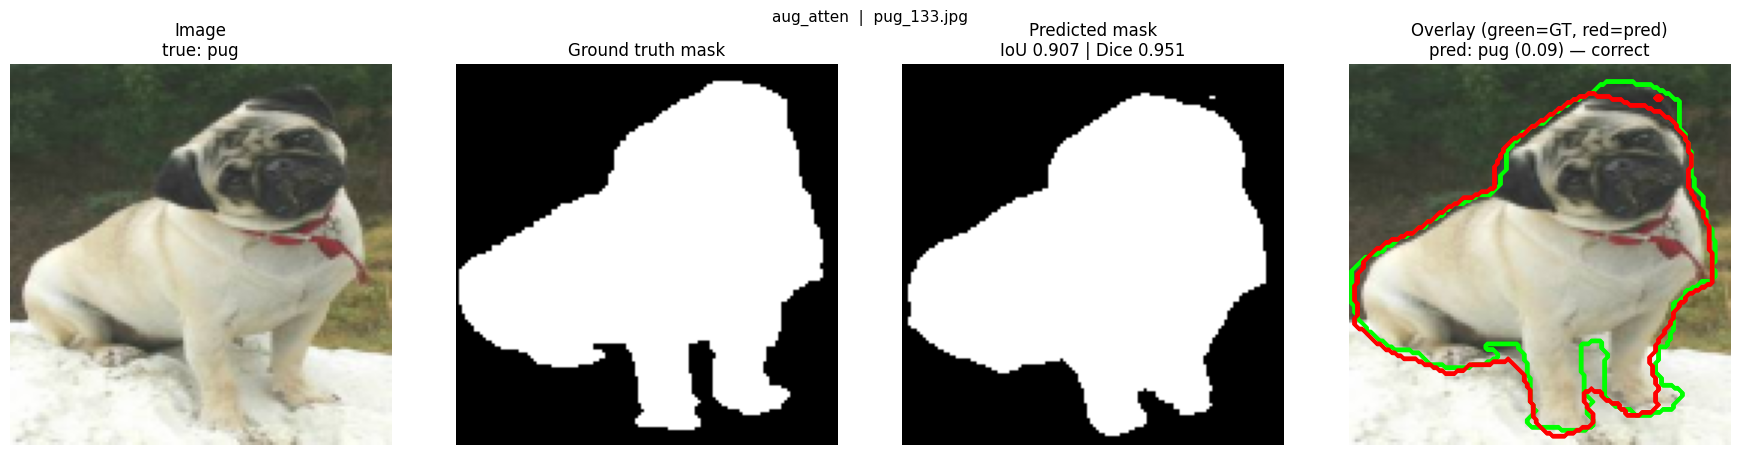

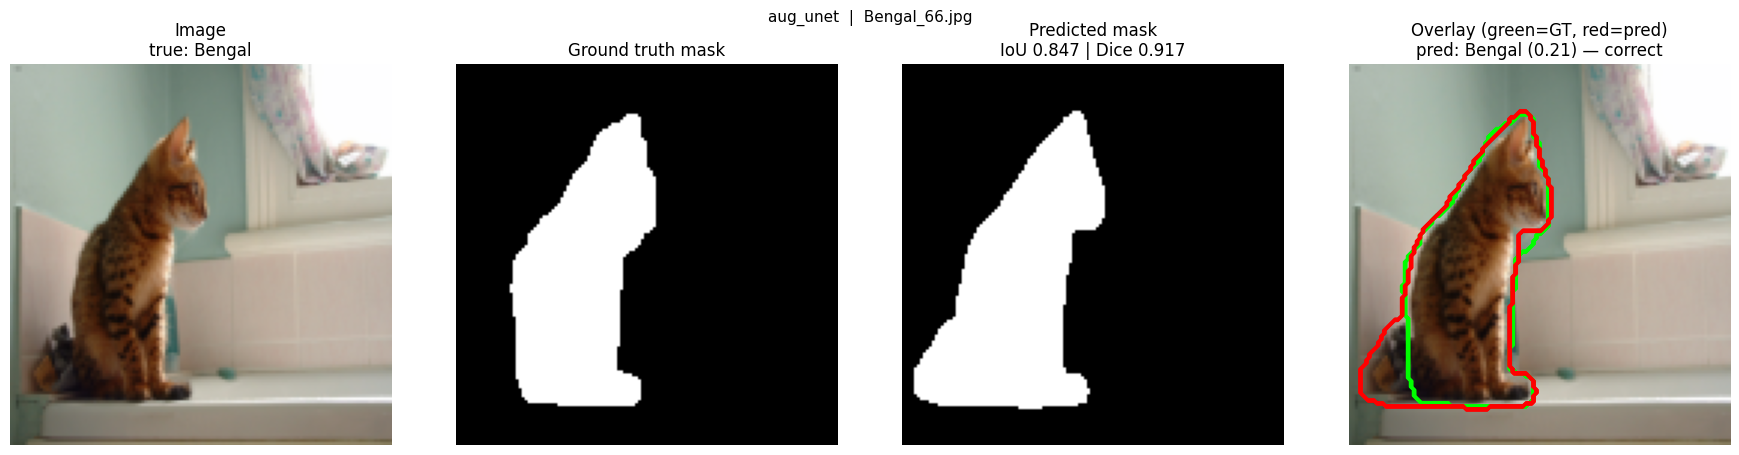

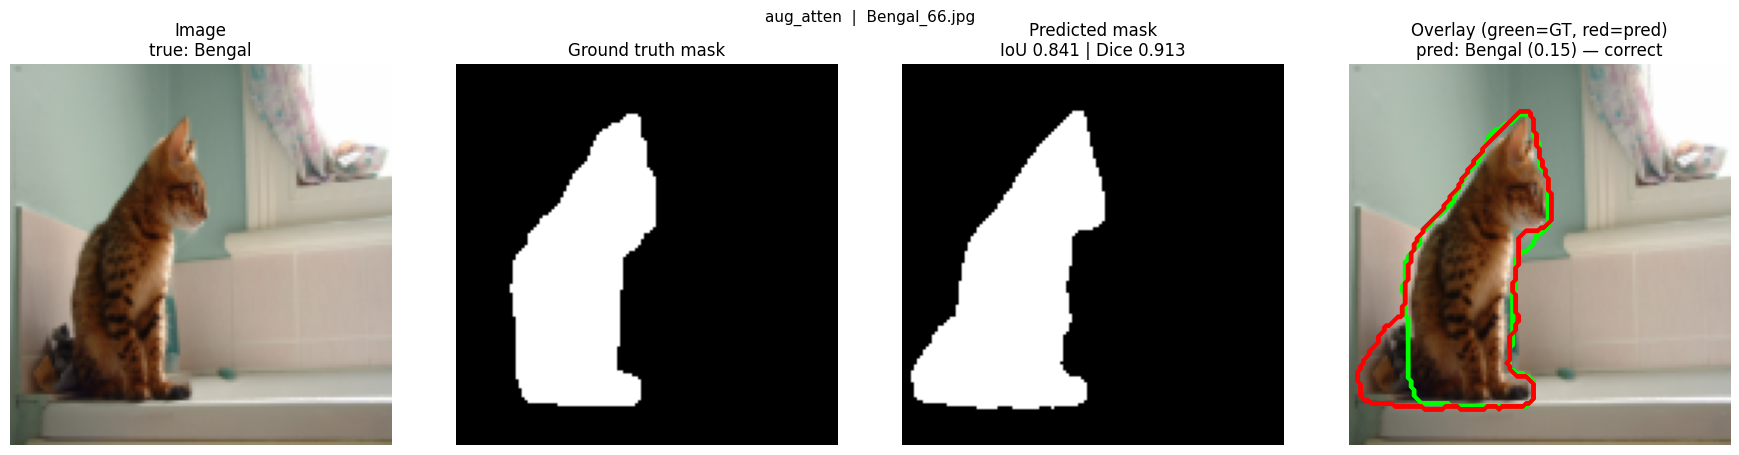

In [ ]:
import matplotlib.pyplot as plt

_MODEL_CACHE = {}

def get_model(tag):
    if tag not in _MODEL_CACHE:
        enc, bot, dec, cls = build_and_load(tag)
        for m in (enc, bot, dec, cls): m.eval()
        _MODEL_CACHE[tag] = (enc, bot, dec, cls)
    return _MODEL_CACHE[tag]


def _denorm(img_t, mean=None, std=None):
    mean = MEAN if mean is None else mean
    std  = STD  if std  is None else std
    return (img_t.cpu() * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()


@torch.inference_mode()
def show_prediction(idx, tag="unet_aug2", files=None, thresh=0.5):
    """Takes an image index, runs it through the model, displays the results."""
    files = test_files if files is None else files
    enc, bot, dec, cls = get_model(tag)

    ds = NormalizedPetDataset(files, augment=False)
    img_t, mask_t, label_t = ds[idx]

    x = img_t.unsqueeze(0).to(device)
    x1, x2, x3, x4 = enc(x)
    x5 = bot(x4)
    seg_logits = dec(x5, x4, x3, x2, x1)          # [1, H, W] raw logits
    cls_logits = cls(x5)

    prob      = torch.sigmoid(seg_logits)[0].cpu().numpy()
    pred_mask = (prob > thresh).astype(np.float32)
    gt        = mask_t.numpy()

    inter = (pred_mask * gt).sum()
    iou   = inter / (pred_mask.sum() + gt.sum() - inter + 1e-6)
    dice  = 2 * inter / (pred_mask.sum() + gt.sum() + 1e-6)

    probs     = torch.softmax(cls_logits, dim=1)[0]
    pred_idx  = int(probs.argmax())
    true_name = breeds_all[label_t.item()]
    pred_name = breeds_all[pred_idx]
    ok        = "correct" if pred_idx == label_t.item() else "WRONG"

    img_disp = _denorm(img_t)
    fig, ax = plt.subplots(1, 4, figsize=(18, 4.6))
    ax[0].imshow(img_disp);                 ax[0].set_title(f"Image\ntrue: {true_name}")
    ax[1].imshow(gt, cmap="gray");          ax[1].set_title("Ground truth mask")
    ax[2].imshow(pred_mask, cmap="gray");   ax[2].set_title(f"Predicted mask\nIoU {iou:.3f} | Dice {dice:.3f}")
    ax[3].imshow(img_disp)
    ax[3].contour(gt,        colors="lime",   linewidths=1.5)
    ax[3].contour(pred_mask, colors="red",    linewidths=1.5)
    ax[3].set_title(f"Overlay (green=GT, red=pred)\npred: {pred_name} ({probs[pred_idx]:.2f}) — {ok}")
    for a in ax: a.axis("off")
    fig.suptitle(f"{MODEL_DISPLAY_NAMES.get(tag, tag)}  |  {files[idx]}", fontsize=11)
    plt.tight_layout(); plt.show()


# demo: same random indices through both models, side by side
demo_indices = random.sample(range(len(test_files)), 3)
for i in demo_indices:
    for tag in AUGMENTED_TAGS:
        show_prediction(i, tag=tag)

In [ ]:
def preprocess_any_image(path, img_size=IMG_SIZE):
    """Same preprocessing as PetDataset, for an arbitrary image file."""
    img = io.imread(path)
    if img.ndim == 2:
        img = np.stack([img] * 3, axis=-1)
    elif img.ndim == 3 and img.shape[-1] == 4:
        img = img[:, :, :3]
    elif img.ndim == 3 and img.shape[-1] == 1:
        img = np.repeat(img, 3, axis=-1)
    assert img.ndim == 3 and img.shape[-1] == 3, f"Bad shape {img.shape}"

    img = transform.resize(img_as_float(img), (img_size, img_size, 3), anti_aliasing=True)
    img_t = torch.tensor(img.copy(), dtype=torch.float32).permute(2, 0, 1)
    return (img_t - MEAN) / (STD + 1e-8)


@torch.inference_mode()
def predict_new_image(path, tag="unet_aug2", topk=3, thresh=0.5):
    enc, bot, dec, cls = get_model(tag)
    img_t = preprocess_any_image(path)

    x = img_t.unsqueeze(0).to(device)
    x1, x2, x3, x4 = enc(x)
    x5 = bot(x4)
    pred_mask = (torch.sigmoid(dec(x5, x4, x3, x2, x1))[0] > thresh).cpu().numpy().astype(np.float32)
    probs = torch.softmax(cls(x5), dim=1)[0].cpu()

    vals, idxs = probs.topk(topk)
    img_disp = _denorm(img_t)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4.6))
    ax[0].imshow(img_disp);               ax[0].set_title("Input")
    ax[1].imshow(pred_mask, cmap="gray"); ax[1].set_title("Predicted mask")
    ax[2].imshow(img_disp)
    ax[2].contour(pred_mask, colors="red", linewidths=1.5)
    ax[2].set_title("Overlay")
    for a in ax: a.axis("off")
    plt.suptitle(" | ".join(f"{breeds_all[i]} {v:.2f}" for v, i in zip(vals, idxs)), fontsize=11)
    plt.tight_layout(); plt.show()
    return [(breeds_all[i], float(v)) for v, i in zip(vals, idxs)]

**Loss curve**

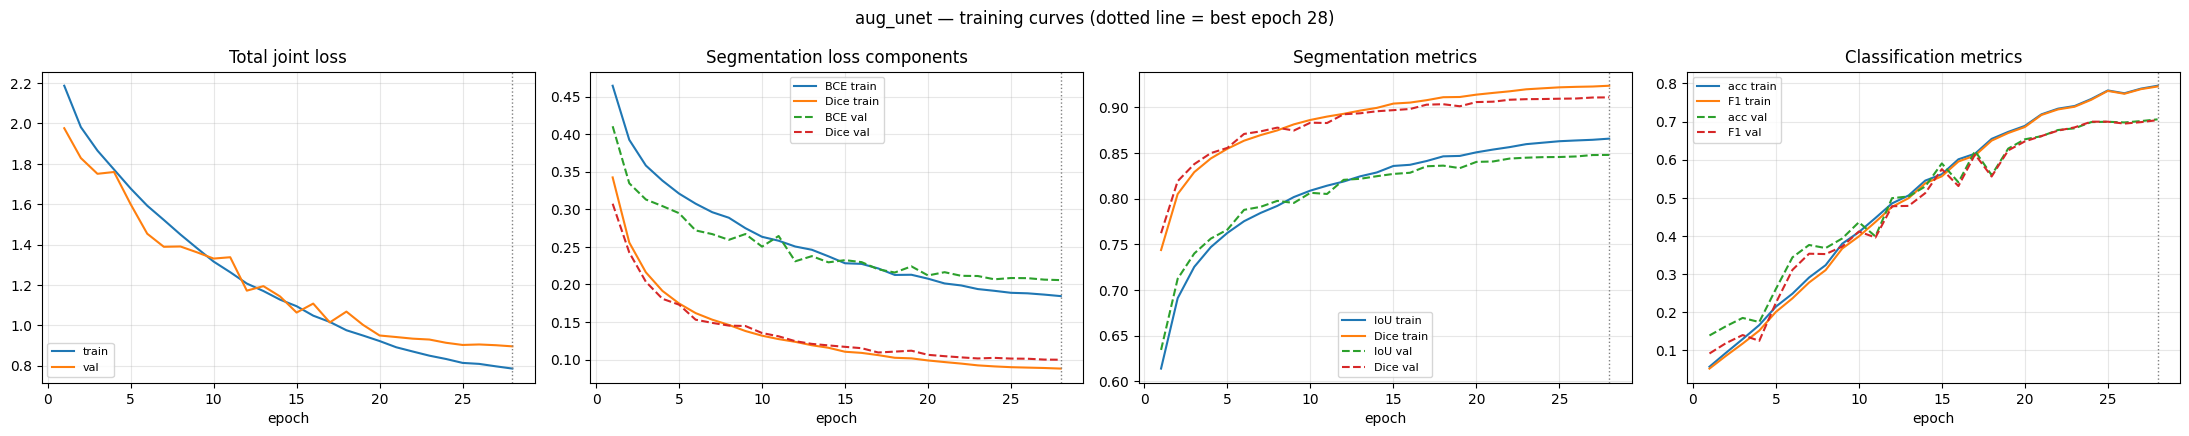

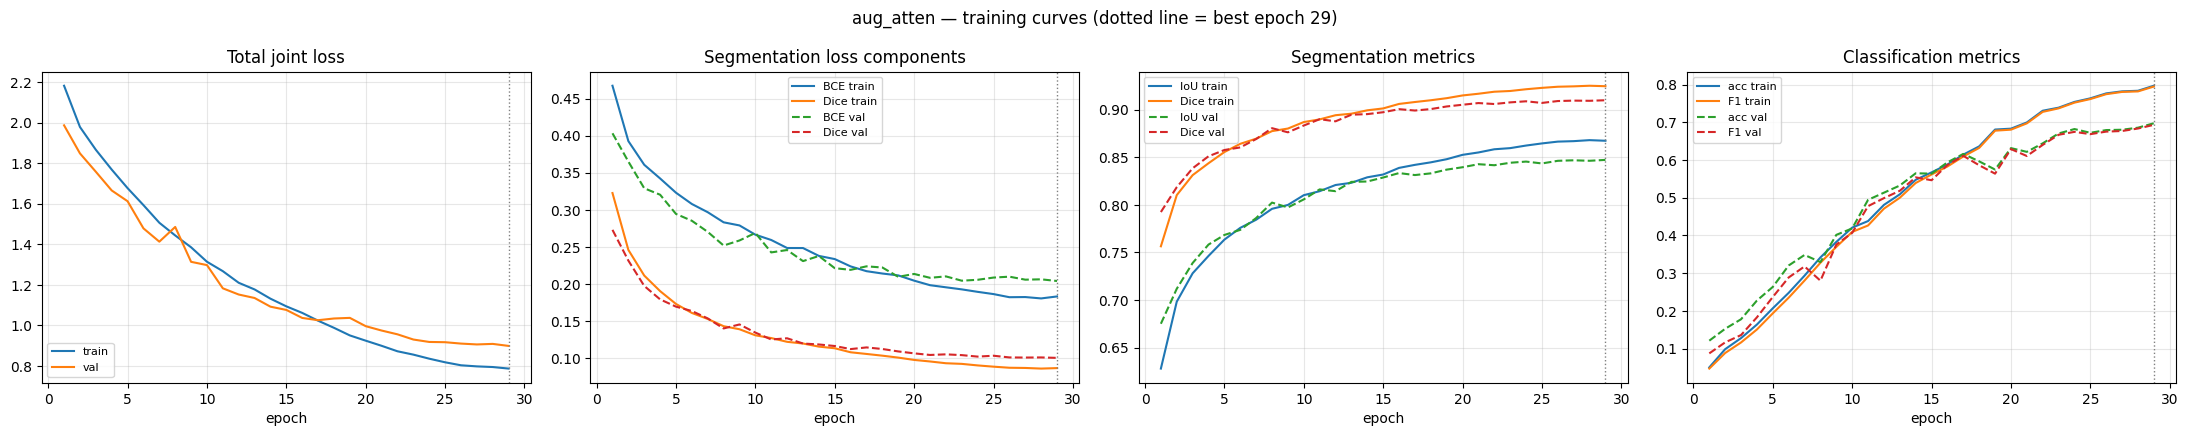

In [ ]:
def plot_history(tag):
    ck = load_ckpt(_ckpt_path(tag))
    h  = ck.get("history", [])
    if not h:
        print(f"No history in {tag}_best.pt"); return
    ep = [r["epoch"] for r in h]

    def total(split):
        return [W_BCE*r[split]["bce"] + W_DICE*r[split]["dice_loss"] + W_CLS*r[split]["cls_loss"] for r in h]

    fig, ax = plt.subplots(1, 4, figsize=(22, 4.4))

    ax[0].plot(ep, total("train"), label="train"); ax[0].plot(ep, total("val"), label="val")
    ax[0].set_title("Total joint loss"); ax[0].set_xlabel("epoch")

    for split, ls in (("train", "-"), ("val", "--")):
        ax[1].plot(ep, [r[split]["bce"] for r in h], ls, label=f"BCE {split}")
        ax[1].plot(ep, [r[split]["dice_loss"] for r in h], ls, label=f"Dice {split}")
    ax[1].set_title("Segmentation loss components"); ax[1].set_xlabel("epoch")

    for split, ls in (("train", "-"), ("val", "--")):
        ax[2].plot(ep, [r[split]["iou"] for r in h], ls, label=f"IoU {split}")
        ax[2].plot(ep, [r[split]["dice_coef"] for r in h], ls, label=f"Dice {split}")
    ax[2].set_title("Segmentation metrics"); ax[2].set_xlabel("epoch")

    for split, ls in (("train", "-"), ("val", "--")):
        ax[3].plot(ep, [r[split]["cls_acc"] for r in h], ls, label=f"acc {split}")
        ax[3].plot(ep, [r[split]["cls_f1"] for r in h], ls, label=f"F1 {split}")
    ax[3].set_title("Classification metrics"); ax[3].set_xlabel("epoch")

    best = max(h, key=lambda r: r["val"]["cls_acc"])["epoch"]
    for a in ax:
        a.axvline(best, color="gray", ls=":", lw=1)
        a.legend(fontsize=8); a.grid(alpha=0.3)
    fig.suptitle(f"{MODEL_DISPLAY_NAMES.get(tag, tag)} — training curves (dotted line = best epoch {best})")
    plt.tight_layout(); plt.show()

for tag in AUGMENTED_TAGS:
    plot_history(tag)

**Random image from test set**

Testing on: chihuahua_21.jpg


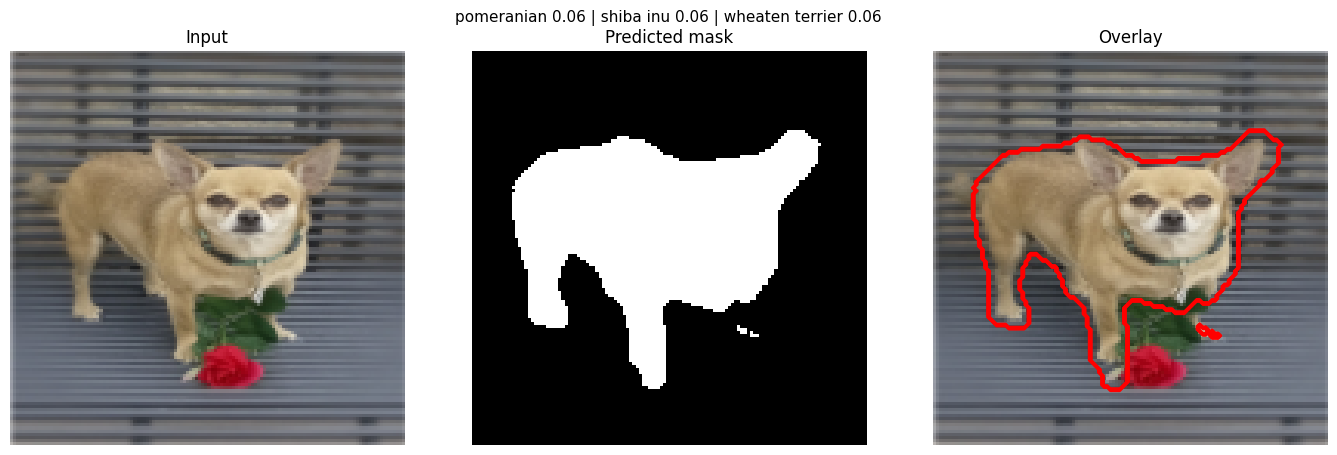

[('pomeranian', 0.06475751101970673),
 ('shiba inu', 0.06397499889135361),
 ('wheaten terrier', 0.057367291301488876)]

In [ ]:
import random

random_idx = random.randint(0, len(test_files)-1)
test_image = os.path.join(IMG_DIR, test_files[random_idx])
print(f"Testing on: {test_files[random_idx]}")

predict_new_image(test_image, tag="unet_aug2")

**Input image test**


Processing Image 1/5: Abyssinian_10.jpg


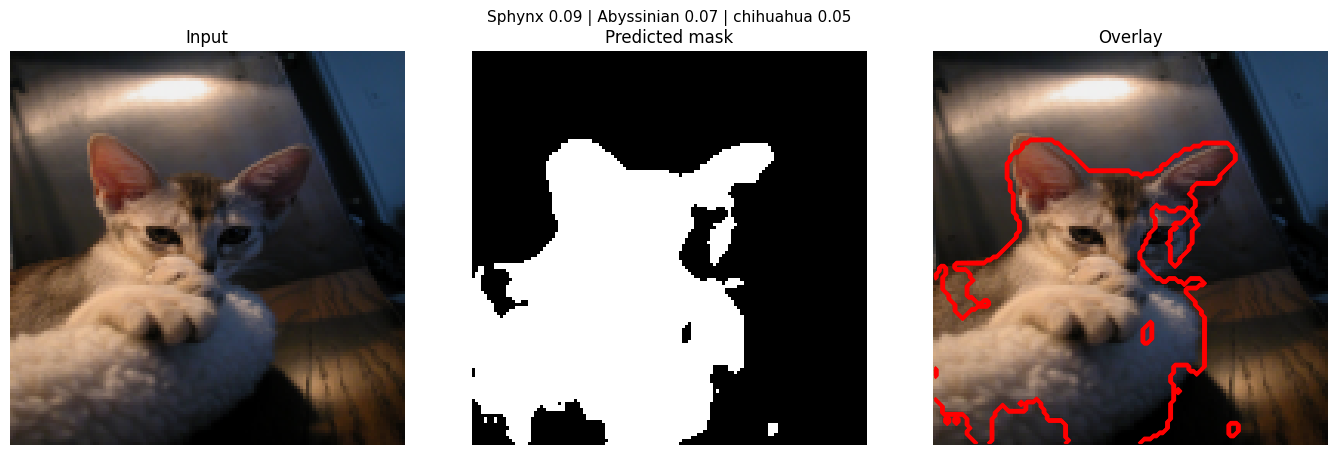

UNet - Result: ('Sphynx', 0.08510804921388626)


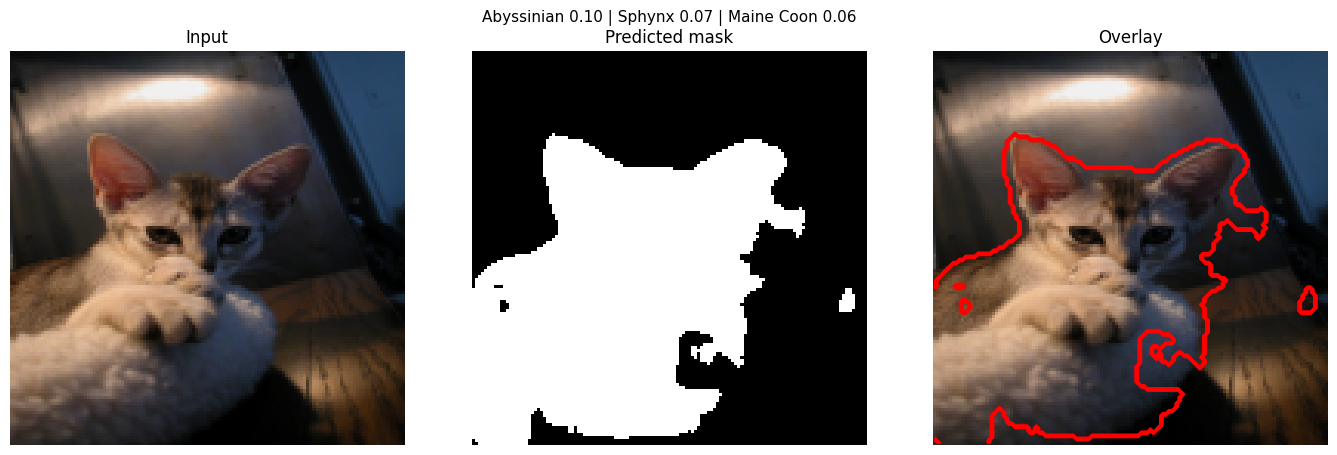

Attn UNet - Result: ('Abyssinian', 0.10296656936407089)

Processing Image 2/5: american_bulldog_131.jpg


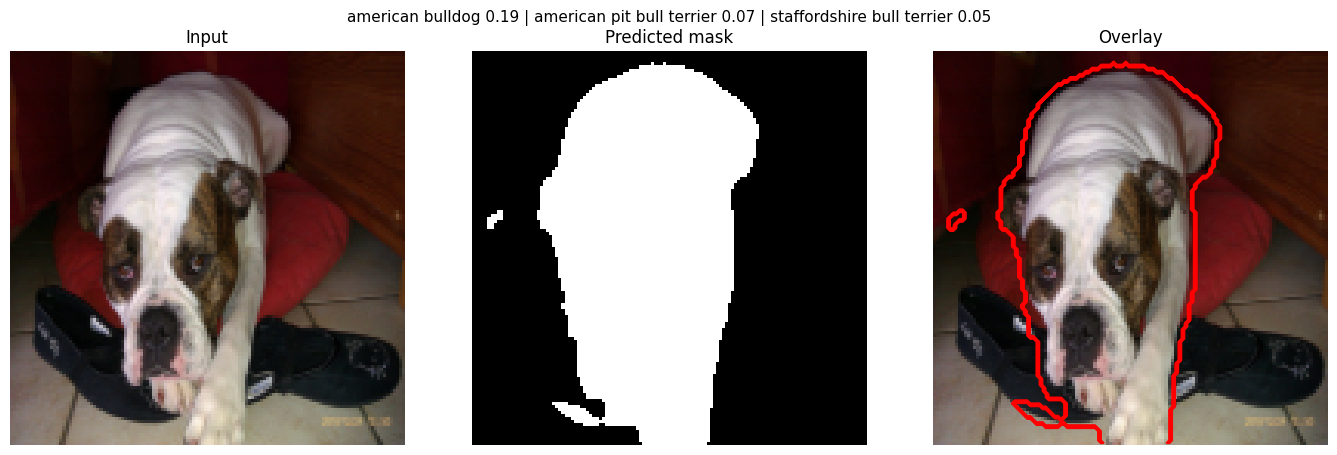

UNet - Result: ('american bulldog', 0.18913403153419495)


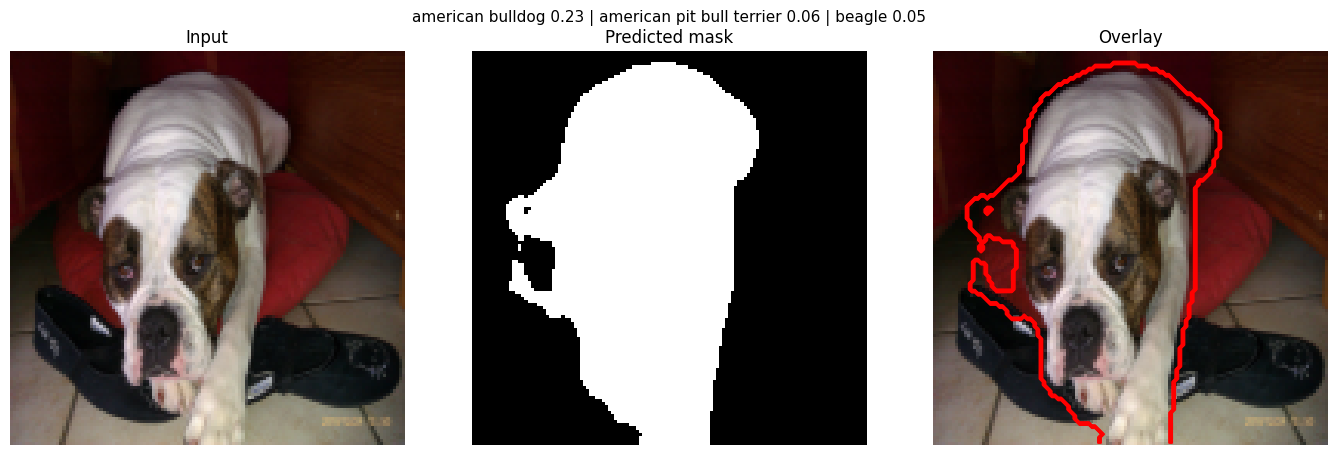

Attn UNet - Result: ('american bulldog', 0.2270246297121048)

Processing Image 3/5: american_pit_bull_terrier_14.jpg


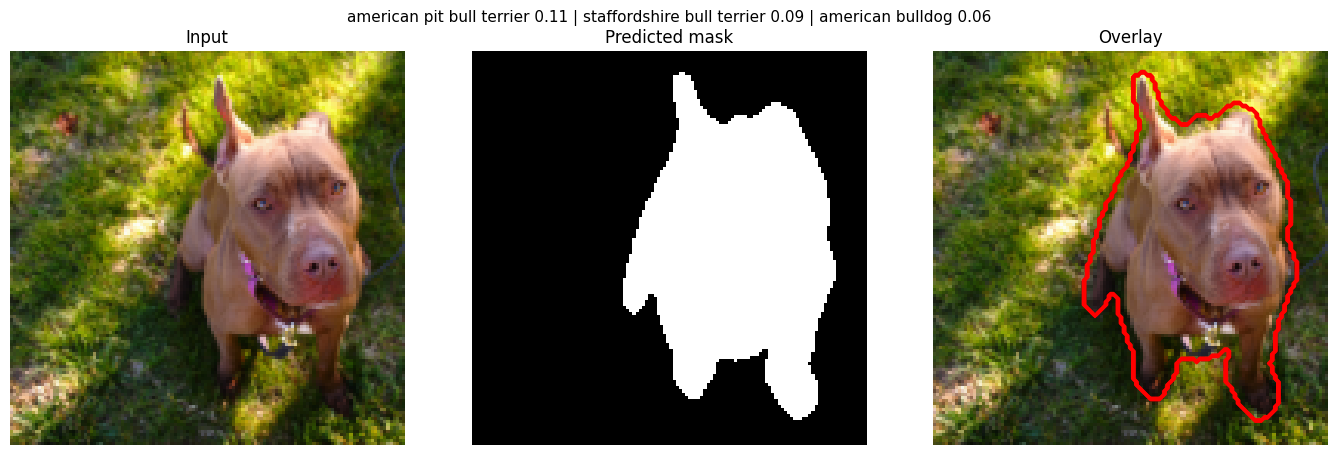

UNet - Result: ('american pit bull terrier', 0.10969000309705734)


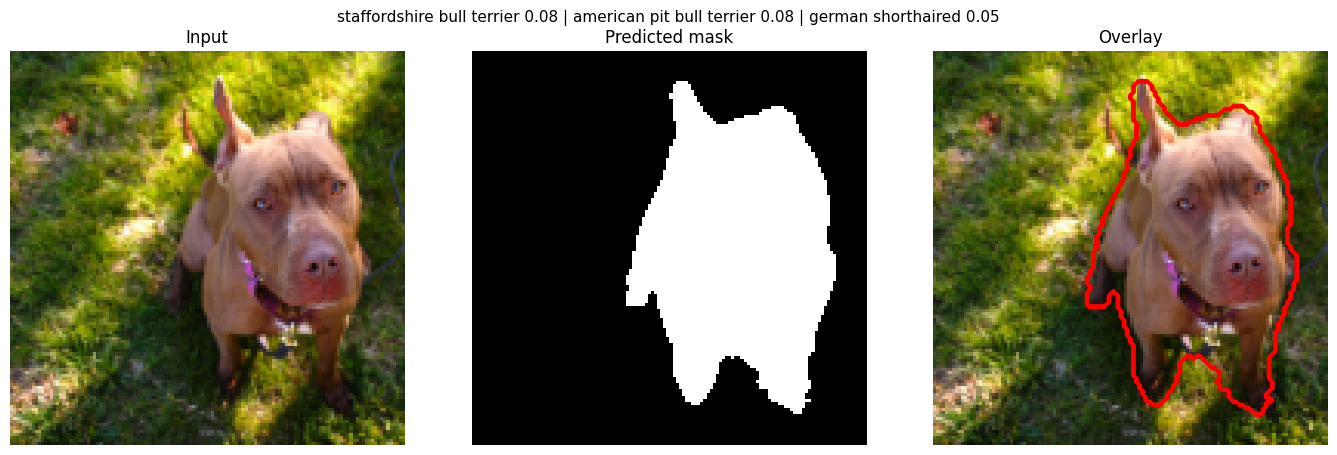

Attn UNet - Result: ('staffordshire bull terrier', 0.08120773732662201)

Processing Image 4/5: basset_hound_148.jpg


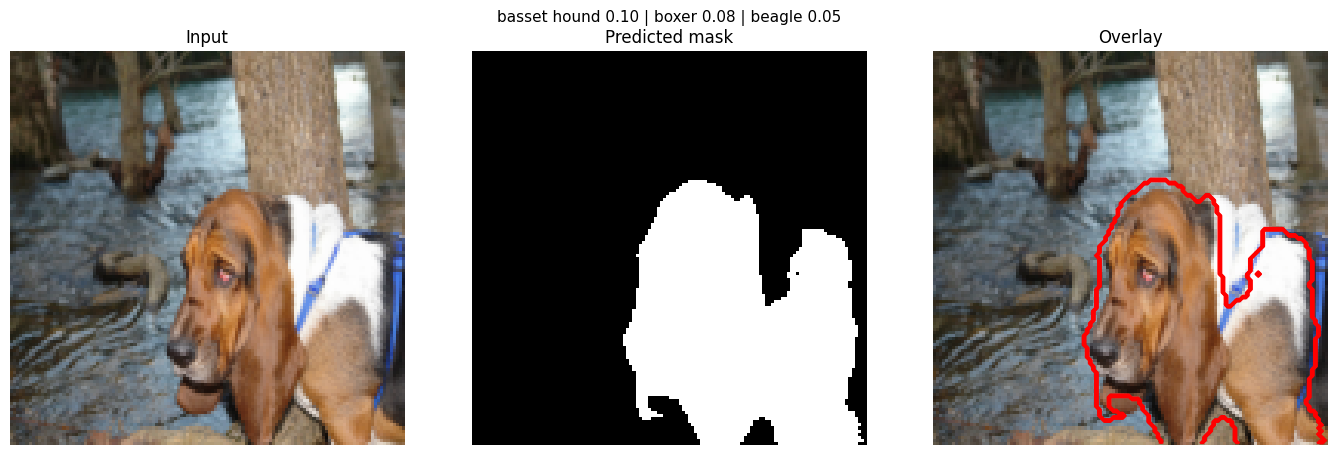

UNet - Result: ('basset hound', 0.09558382630348206)


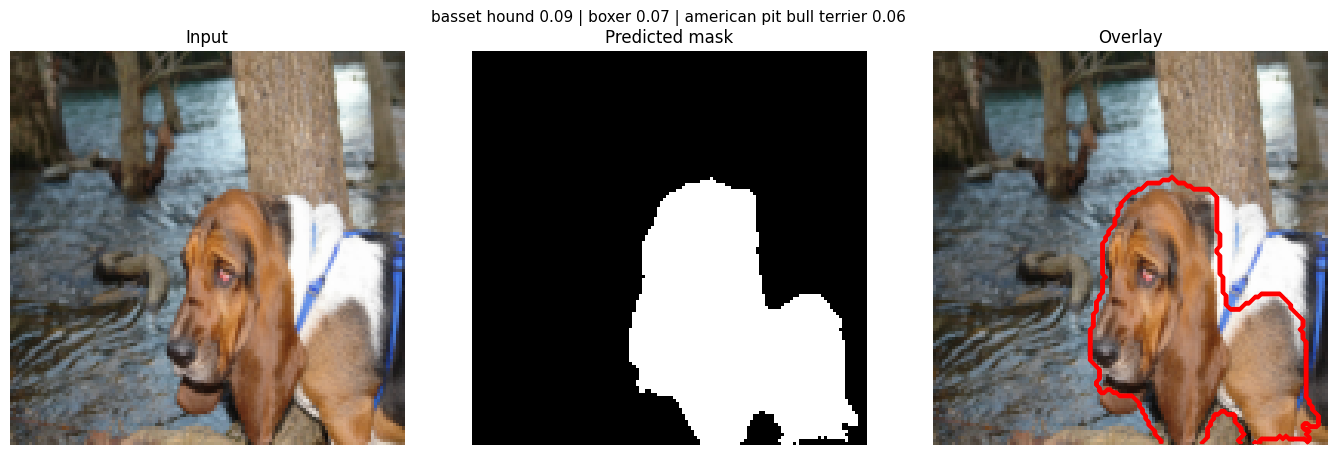

Attn UNet - Result: ('basset hound', 0.08962012082338333)

Processing Image 5/5: beagle_84.jpg


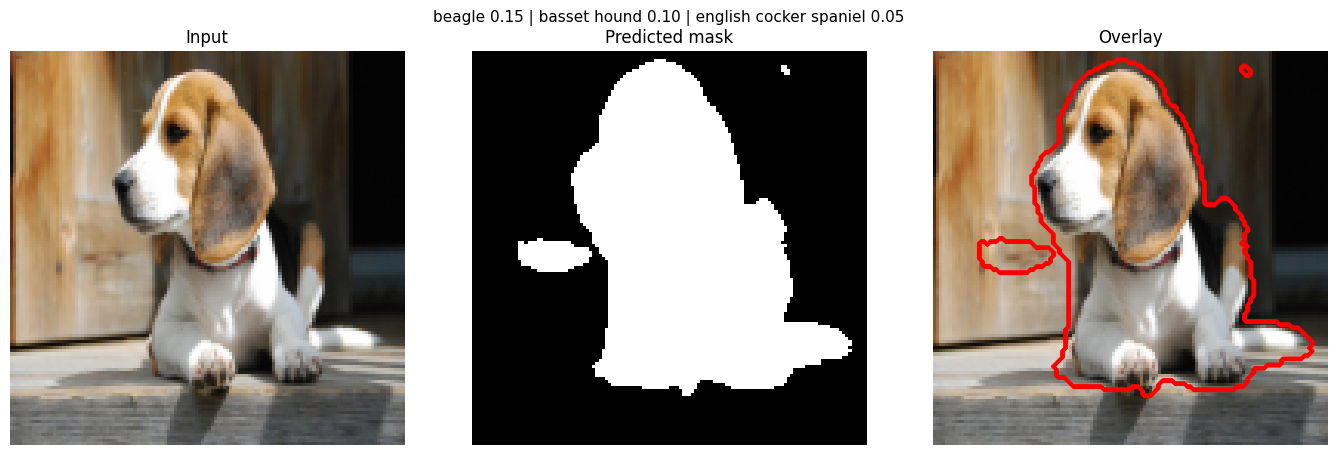

UNet - Result: ('beagle', 0.14699801802635193)


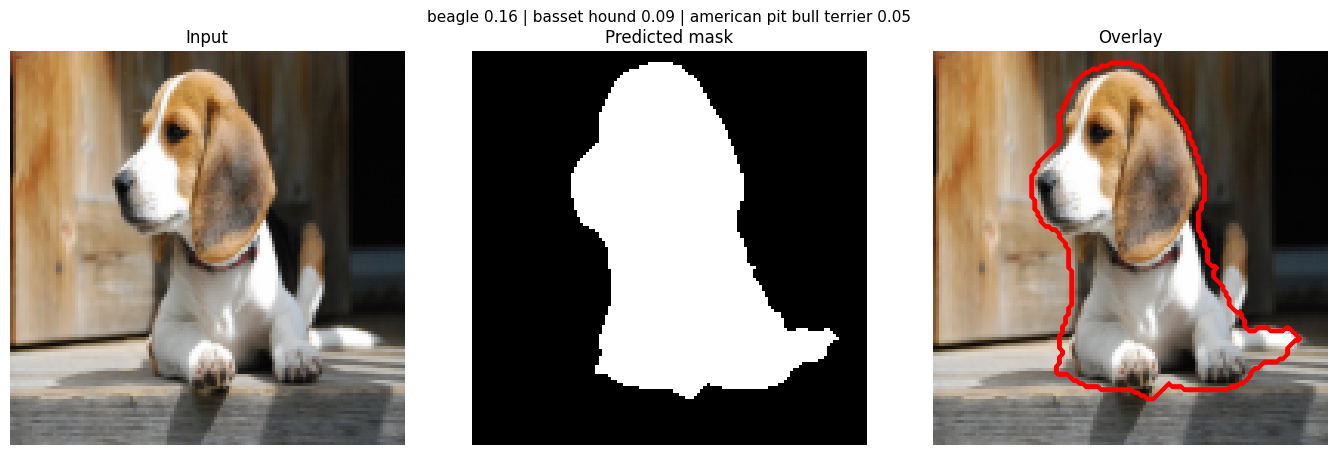

Attn UNet - Result: ('beagle', 0.15755034983158112)

Completed processing all images!


In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np

# List of your 5 image paths
image_paths = [
    "/content/Abyssinian_10.jpg",
    "/content/american_bulldog_131.jpg",
    "/content/american_pit_bull_terrier_14.jpg",
    "/content/basset_hound_148.jpg",
    "/content/beagle_84.jpg"
]

# Process each image
all_results_unet = []
all_results_attn = []

for i, img_path in enumerate(image_paths):
    print(f"\n{'='*60}")
    print(f"Processing Image {i+1}/{len(image_paths)}: {os.path.basename(img_path)}")
    print('='*60)

    # Check if file exists
    if not os.path.exists(img_path):
        print(f"File not found: {img_path}")
        continue

    # Predict with UNet
    result_unet = predict_new_image(img_path, tag="unet_aug2")

    # Handle different return types
    if isinstance(result_unet, (list, tuple)):
        result_unet = result_unet[0]  # Extract first element
    all_results_unet.append(result_unet)

    # Print results based on type
    if isinstance(result_unet, dict):
        print(f"UNet - Breed: {result_unet.get('breed', 'Unknown')}, Accuracy: {result_unet.get('accuracy', 0):.2%}")
    else:
        print(f"UNet - Result: {result_unet}")

    # Predict with Attention UNet
    result_attn = predict_new_image(img_path, tag="attn_aug2")

    # Handle different return types
    if isinstance(result_attn, (list, tuple)):
        result_attn = result_attn[0]  # Extract first element
    all_results_attn.append(result_attn)

    if isinstance(result_attn, dict):
        print(f"Attn UNet - Breed: {result_attn.get('breed', 'Unknown')}, Accuracy: {result_attn.get('accuracy', 0):.2%}")
    else:
        print(f"Attn UNet - Result: {result_attn}")

print(f"\n{'='*60}")
print("Completed processing all images!")